#**Model Training And save that**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#RANDOM FOREST:

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import nltk
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import LabelEncoder
import joblib

nltk.download('punkt_tab')

# Load the labeled dataset
file_path = '/content/drive/MyDrive/FYP/exploded_keywords_labeled.csv'
df = pd.read_csv(file_path)

# Ensure no missing values
df = df.dropna(subset=['Keyword', 'Label'])

# Get the value counts for each Emergency_Type
emergency_type_counts = df['Label'].value_counts()

# Filter out classes with only one sample
df = df[df['Label'].isin(emergency_type_counts[emergency_type_counts > 1].index)]

# Convert text data to numerical vectors using TF-IDF
vectorizer = TfidfVectorizer(tokenizer=word_tokenize, stop_words='english', max_features=5000)
X = vectorizer.fit_transform(df['Keyword'])

# Encode the emergency type labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Label'])


# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Added stratify=y to ensure all classes are represented in train and test sets

# Define the Random Forest model
rf = RandomForestClassifier(random_state=42)

# Define the hyperparameters for tuning
param_grid = {
    'n_estimators': [100, 200, 300],        # Number of trees in the forest
    'max_depth': [10, 20, 30, None],       # Maximum depth of each tree
    'min_samples_split': [2, 5, 10],       # Minimum number of samples to split a node
    'min_samples_leaf': [1, 2, 4],         # Minimum number of samples at a leaf node
    'bootstrap': [True, False]             # Whether to use bootstrapping
}

# Use GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='accuracy', verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Retrieve the best model
best_rf = grid_search.best_estimator_

# Evaluate the best model on the test set
y_pred = best_rf.predict(X_test)
print("Classification Report:")

# Get the labels present in the test set
labels = list(set(y_test))
# Get the corresponding class names for these labels
target_names = [label_encoder.classes_[label] for label in labels]

print(classification_report(y_test, y_pred, labels=labels, target_names=target_names)) # Pass labels and target_names
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Fitting 3 folds for each of 216 candidates, totalling 648 fits


/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Classification Report:
               precision    recall  f1-score   support

Accident_Call       1.00      0.98      0.99       133
    Fire_Call       0.88      1.00      0.94       112
 Medical_Call       1.00      1.00      1.00       125
  Normal_Call       1.00      0.85      0.92        85

     accuracy                           0.97       455
    macro avg       0.97      0.96      0.96       455
 weighted avg       0.97      0.97      0.97       455

Accuracy: 0.97


In [ ]:
# Save the model, vectorizer, and label encoder in .p files
joblib.dump(best_rf, '/content/drive/MyDrive/FYP/best_random_forest_model_Key_Ex.p')
joblib.dump(vectorizer, '/content/drive/MyDrive/FYP/tfidf_vectorizer_Key_Ex.p')
joblib.dump(label_encoder, '/content/drive/MyDrive/FYP/label_encoder_Key_Ex.p')

print("Model, vectorizer, and label encoder saved successfully.")

Model, vectorizer, and label encoder saved successfully.


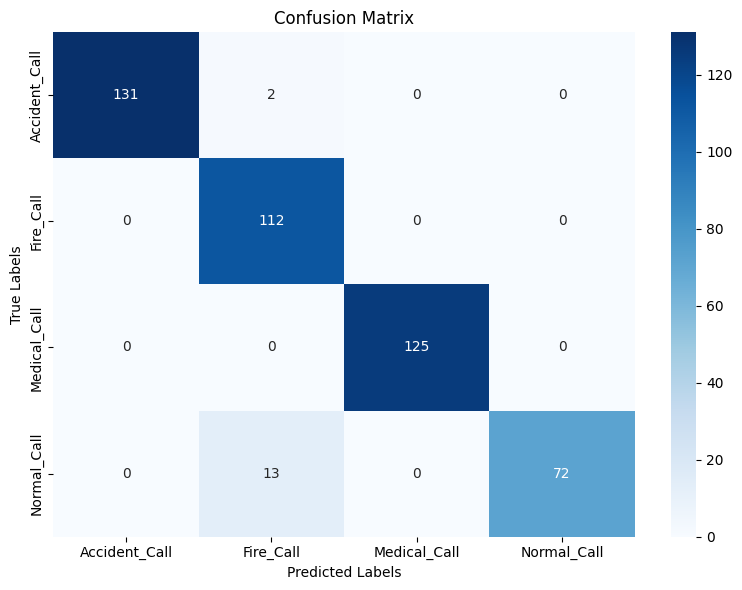

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=labels)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import  RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("/content/drive/MyDrive/FYP/final_keywords_emergency_index.csv")

# Drop rows with missing 'Keyword'
df = df.dropna(subset=['Lemmatized_Transcription'])

# Features and labels
X = df['Lemmatized_Transcription']
y = df['Label']

# Vectorize the text
vectorizer = TfidfVectorizer()
X_vec = vectorizer.fit_transform(X)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier()
}

# Train and evaluate
accuracy_scores = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    accuracy_scores[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")



Logistic Regression Accuracy: 0.9129
KNN Accuracy: 0.8921
Random Forest Accuracy: 0.9668


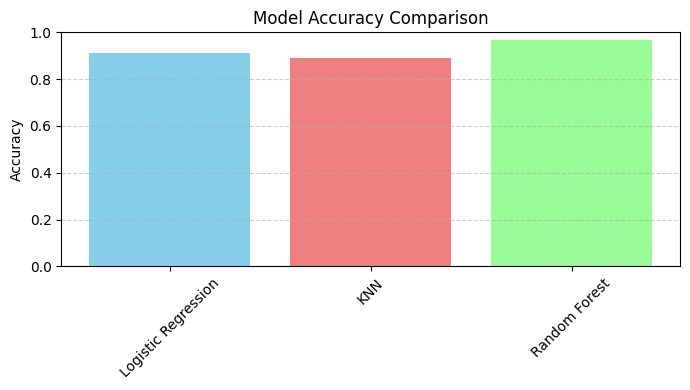

In [ ]:
import matplotlib.pyplot as plt

# Color list (you can customize these)
colors = ['skyblue', 'lightcoral', 'palegreen', 'plum', 'gold']

# Plotting
plt.figure(figsize=(7, 4))
plt.bar(accuracy_scores.keys(), accuracy_scores.values(), color=colors)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



